<a href="https://colab.research.google.com/github/Hala-sala7/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales
- Auther : Hala Salah

##

## Project Overview

## Load and Inspect Data

In [433]:
from google.colab import drive
drive.mount("/content/Data")
fname = "/content/Data/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv"
import pandas as pd
df = pd.read_csv(fname)

Drive already mounted at /content/Data; to attempt to forcibly remount, call drive.mount("/content/Data", force_remount=True).


In [434]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [435]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Clean Data

In [436]:
df.shape

(8523, 12)

In [437]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [438]:
duplicated_raws=df.duplicated()
duplicated_raws

,0
0,False
1,False
2,False
3,False
4,False
...,...
8518,False
8519,False
8520,False
8521,False


In [439]:
df.duplicated().sum()

np.int64(0)

In [440]:
df.isna()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,False,False,False,False,False,False,False,False,False,False,False,False
8519,False,False,False,False,False,False,False,False,True,False,False,False
8520,False,False,False,False,False,False,False,False,False,False,False,False
8521,False,False,False,False,False,False,False,False,False,False,False,False


In [441]:
null_sums = df.isna().sum()
null_sums

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [442]:
null_persent = null_sums/len(df) *100
null_persent

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


<Axes: >

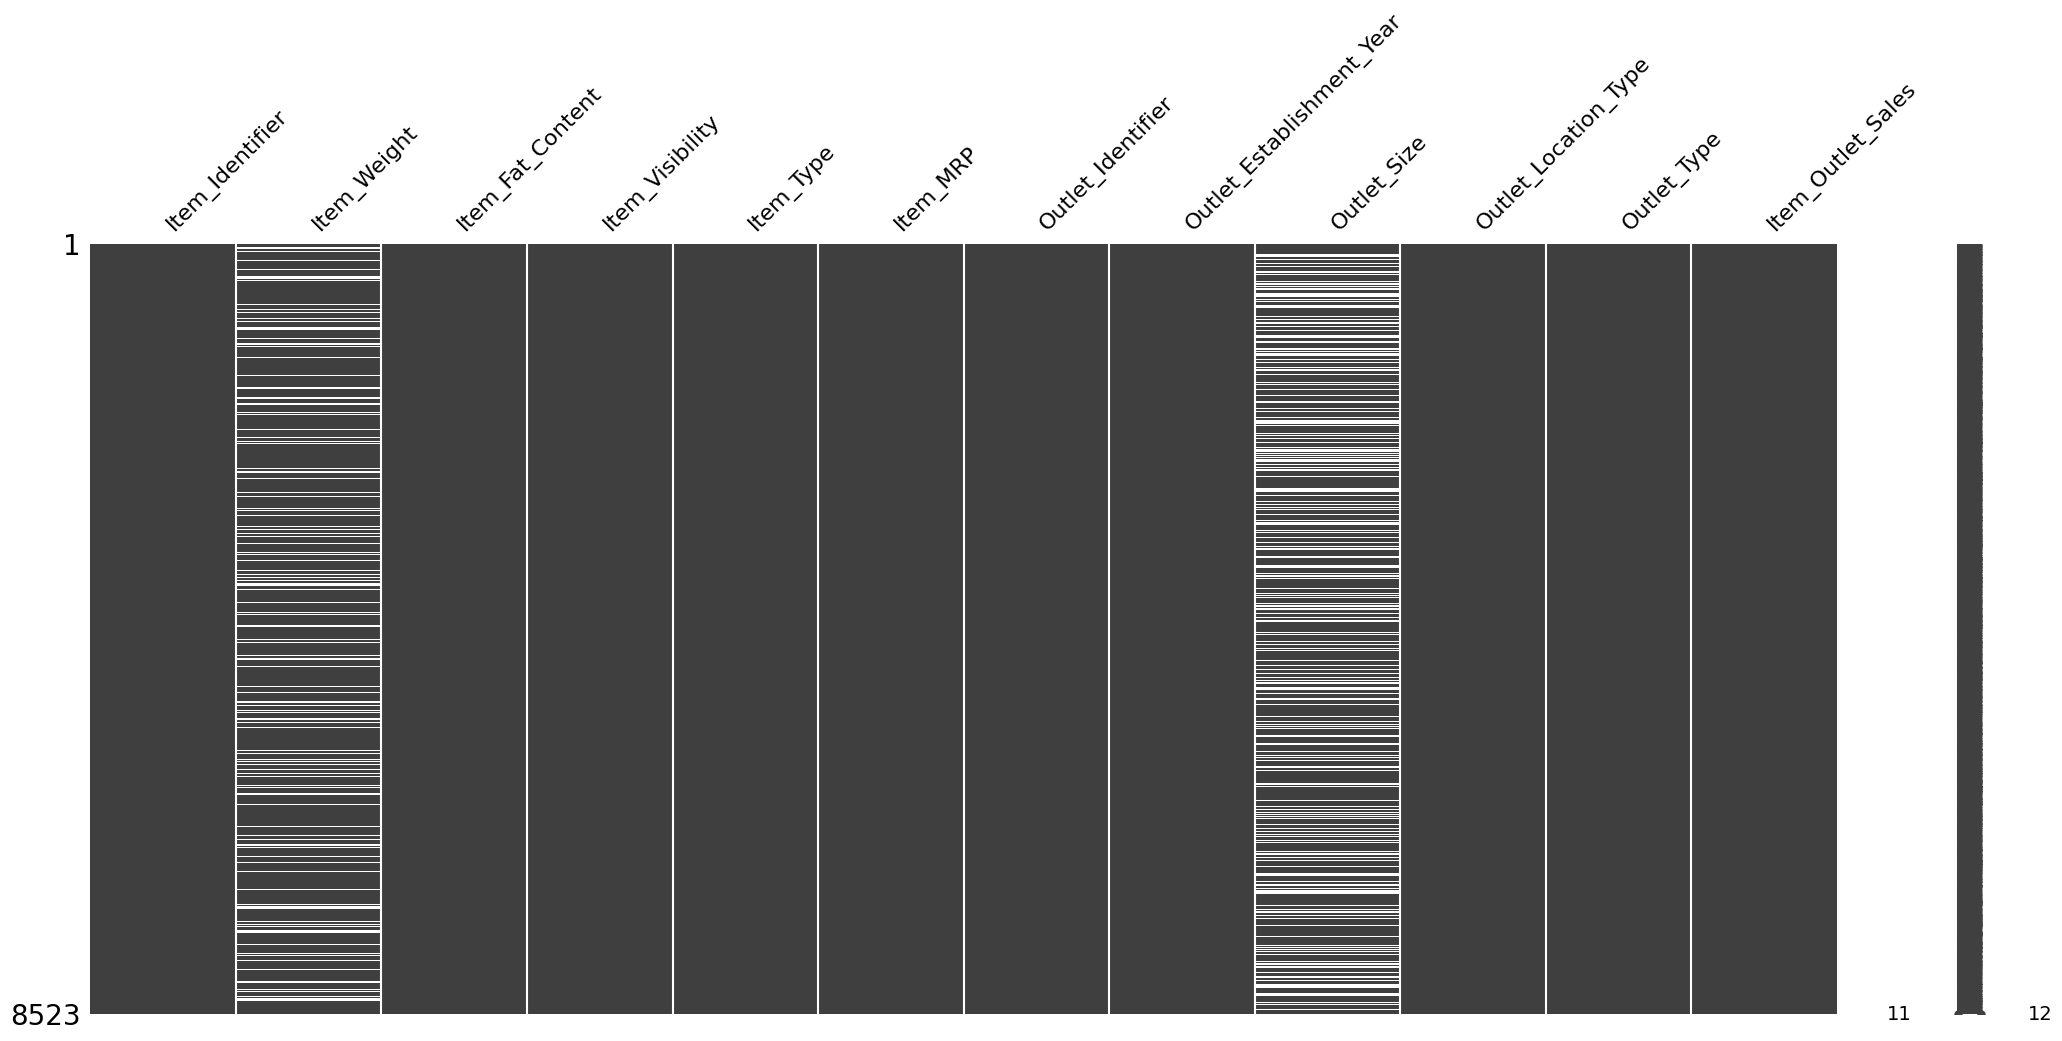

In [443]:
import missingno as msno
msno.matrix(df)

In [444]:
object_columns = df.select_dtypes('object').columns
object_columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [445]:
number_columns = df.select_dtypes('number').columns
number_columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [446]:
df[object_columns].isna().sum()

,0
Item_Identifier,0
Item_Fat_Content,0
Item_Type,0
Outlet_Identifier,0
Outlet_Size,2410
Outlet_Location_Type,0
Outlet_Type,0


In [447]:
df[number_columns].isna().sum()

,0
Item_Weight,1463
Item_Visibility,0
Item_MRP,0
Outlet_Establishment_Year,0
Item_Outlet_Sales,0


In [448]:
df["Outlet_Size"].isna().sum()

np.int64(2410)

In [449]:

df['Item_Weight'].isna().sum()

np.int64(1463)

In [450]:
for col in object_columns:
  print(f'value Counts for {col}')
  print(df[col].value_counts())
  print('\n')

value Counts for Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


value Counts for Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


value Counts for Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


value Counts for Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013

In [451]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [452]:
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({"Low Fat": "low fat",
    "LF": "low fat",
     "reg":"Regular"})
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
low fat,5517
Regular,3006


In [453]:
df[number_columns].describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Exploratory Data Analysis

In [454]:
number_columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [455]:
import matplotlib.pyplot as plt
import seaborn as sns

In [456]:
sorted(df['Item_Visibility'].unique())

[np.float64(0.0),
 np.float64(0.003574698),
 np.float64(0.003589104),
 np.float64(0.003597678),
 np.float64(0.003599378),
 np.float64(0.003606726),
 np.float64(0.003612411),
 np.float64(0.005209791),
 np.float64(0.005230786),
 np.float64(0.005234153),
 np.float64(0.005235143),
 np.float64(0.005243282),
 np.float64(0.005264755),
 np.float64(0.005448005),
 np.float64(0.00547348),
 np.float64(0.005474515),
 np.float64(0.005485618),
 np.float64(0.005496816),
 np.float64(0.005505481),
 np.float64(0.005525913),
 np.float64(0.00552947),
 np.float64(0.005530516),
 np.float64(0.005539114),
 np.float64(0.005547386),
 np.float64(0.005557062),
 np.float64(0.005561538),
 np.float64(0.005561798),
 np.float64(0.005583951),
 np.float64(0.005611367),
 np.float64(0.005620213),
 np.float64(0.005638944),
 np.float64(0.005661669),
 np.float64(0.005677876),
 np.float64(0.005935001),
 np.float64(0.005949644),
 np.float64(0.005958918),
 np.float64(0.005962753),
 np.float64(0.005963881),
 np.float64(0.00597362

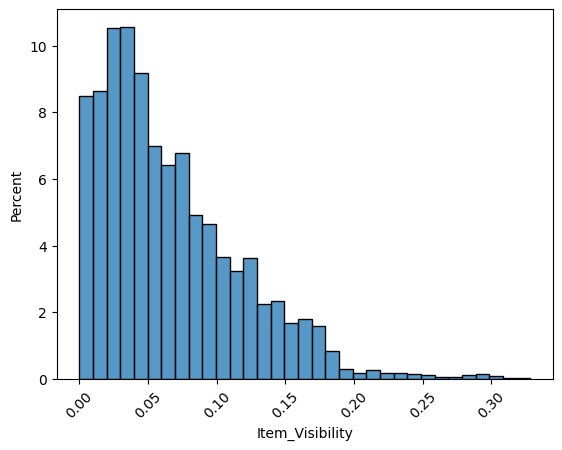

In [457]:
ax = sns.histplot(data=df, x='Item_Visibility', binwidth=0.01, stat='percent')
ax.ticklabel_format(style='plain')
ax.tick_params(axis='x', rotation=45)



The histogram shows that most products have low item visibility in the store, with values concentrated between approximately 0.01 and 0.08. This indicates that most products occupy a small portion of the display area, while only a few products have high visibility in the store.


In [458]:
df['Item_Visibility'].describe()

,Item_Visibility
count,8523.000000
mean,0.066132
std,0.051598
min,0.000000
25%,0.026989
50%,0.053931
75%,0.094585
max,0.328391


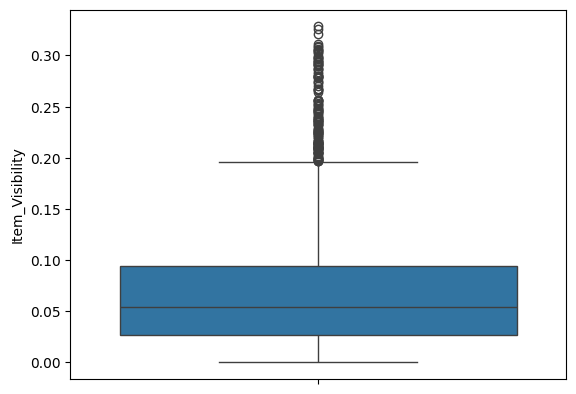

In [459]:
ax=sns.boxplot(data=df,y="Item_Visibility")

The boxplot shows that most products have low item visibility, with a median around 0.05. Most values fall between approximately 0.03 and 0.09, indicating that the majority of products occupy a small portion of the shelf display. There are several high outliers, suggesting that a small number of products receive much higher visibility compared to the rest.

In [460]:
df.select_dtypes('object').nunique()

,0
Item_Identifier,1559
Item_Fat_Content,2
Item_Type,16
Outlet_Identifier,10
Outlet_Size,3
Outlet_Location_Type,3
Outlet_Type,4


In [461]:
df['Outlet_Identifier'].value_counts()

,count
Outlet_Identifier,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555


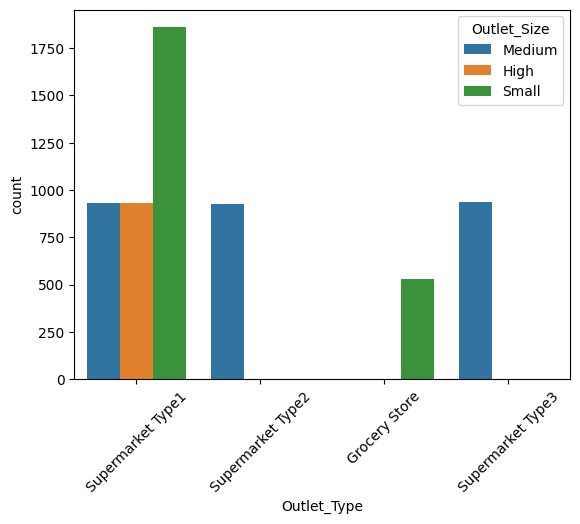

In [462]:
ax = sns.countplot(data=df, x="Outlet_Type", hue="Outlet_Size")
ax.tick_params(axis='x', rotation=45)

The countplot shows the distribution of outlet sizes across different outlet types. Supermarket Type1 appears in all outlet sizes (Small, Medium, and High) and also contains many missing size values, indicating it is the most diverse and common outlet type. Supermarket Type2 and Supermarket Type3 appear only with Medium outlet size, suggesting these supermarket types are typically medium-sized stores. Grocery Stores are mainly associated with Small outlet sizes and some missing values.

In [463]:
core = df.corr(numeric_only=True)
core

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.014048,0.027141,-0.011588,0.014123
Item_Visibility,-0.014048,1.000000,-0.001315,-0.074834,-0.128625
Item_MRP,0.027141,-0.001315,1.000000,0.005020,0.567574
Outlet_Establishment_Year,-0.011588,-0.074834,0.005020,1.000000,-0.049135
Item_Outlet_Sales,0.014123,-0.128625,0.567574,-0.049135,1.000000


<Axes: >

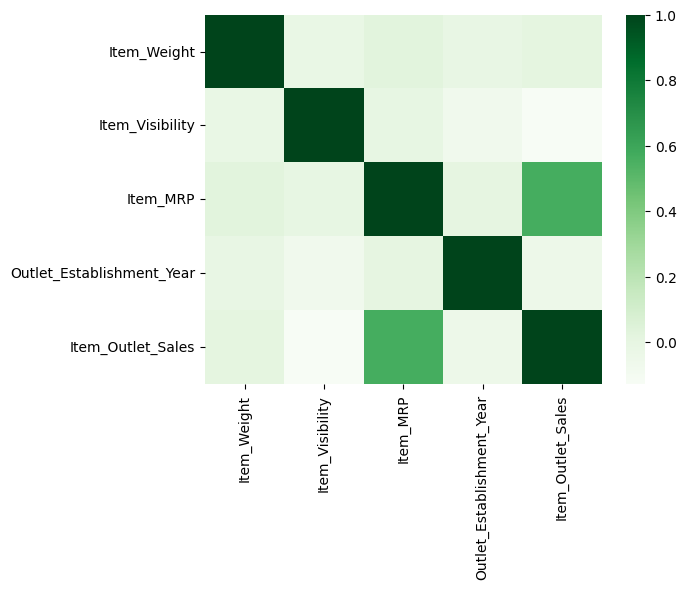

In [464]:
sns.heatmap(core,cmap="Greens")

The positive correlation between Item_MRP and Item_Outlet_Sales occurs because higher priced products tend to generate higher sales revenue.

In [465]:
df['Item_Outlet_Sales'].value_counts().sort_index(ascending=False)

,count
Item_Outlet_Sales,
13086.9648,1
12117.5600,1
11445.1020,1
10993.6896,1
10306.5840,1
...,...
36.6190,2
35.2874,1
34.6216,1


In [466]:
df['Item_Outlet_Sales'].describe()

,Item_Outlet_Sales
count,8523.000000
mean,2181.288914
std,1706.499616
min,33.290000
25%,834.247400
50%,1794.331000
75%,3101.296400
max,13086.964800


Text(0.5, 1.0, 'Distribution of Item Outlet Sales')

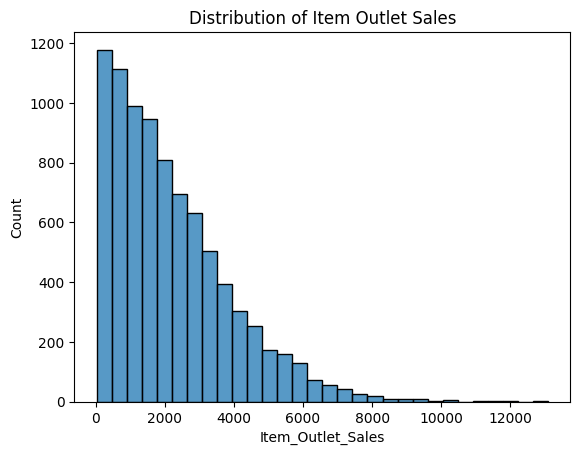

In [467]:
ax = sns.histplot(data=df, x="Item_Outlet_Sales", bins=30)

plt.title("Distribution of Item Outlet Sales")

The histogram shows that Item_Outlet_Sales are right-skewed. Most products generate relatively low to moderate sales, while a small number of products achieve very high sales values, creating a long right tail in the distribution.


In [468]:
df['Item_Outlet_Sales'].isna().sum()

np.int64(0)

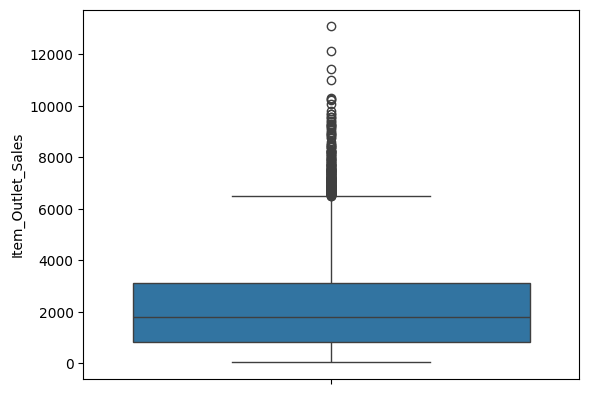

In [469]:
ax=sns.boxplot(data=df,y='Item_Outlet_Sales')

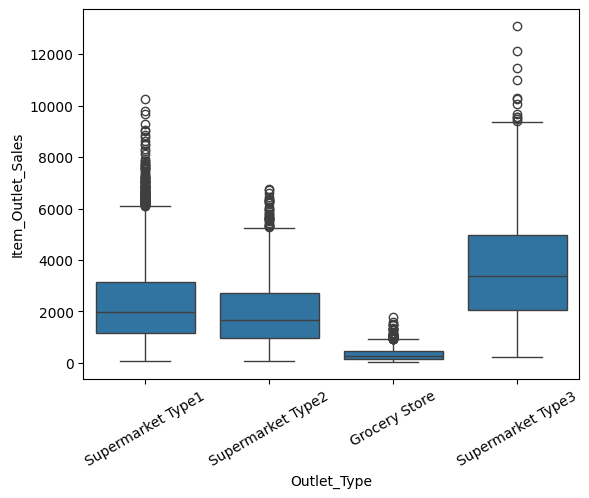

In [470]:
ax=sns.boxplot(data=df, x="Outlet_Type", y="Item_Outlet_Sales")
ax=ax.tick_params(axis='x', rotation=30)


The boxplot shows that Supermarket Type3 has the highest sales distribution among outlet types. Supermarket Type1 and Type2 have moderate sales, while Grocery Stores show the lowest sales values. Several high outliers indicate that some products generate significantly higher sales than others

In [471]:
def explore_categorical(df, x, fillna=True, placeholder='MISSING',
                        figsize=(6,4), order=None):

    # Make a copy of the dataframe
    temp_df = df.copy()

    # Before filling nulls, save null value counts and percent
    null_count = temp_df[x].isna().sum()
    null_perc = null_count / len(temp_df) * 100

    # Fillna with placeholder if enabled
    if fillna == True:
        temp_df[x] = temp_df[x].fillna(placeholder)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Plot countplot
    sns.countplot(data=temp_df, x=x, ax=ax, order=order)

    # Rotate x labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Add title
    ax.set_title(f"Column: {x}")

    # Layout and show plot
    fig.tight_layout()
    plt.show()

    # Print null info
    print(f"-- NaN's Found: {null_count} ({round(null_perc,2)}%)")

    # Print cardinality
    nunique = temp_df[x].nunique()
    print(f"-- Unique Values: {nunique}")

    # Value counts
    val_counts = temp_df[x].value_counts(dropna=False)

    # Most common value
    most_common_val = val_counts.index[0]

    # Frequency
    freq = val_counts.values[0]

    # Percentage
    perc_most_common = freq / len(temp_df) * 100

    # Print results
    print(f"-- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

    # Check if quasi-constant
    if perc_most_common > 98:
        print(f"\n[!] Warning: {x} is a constant or quasi-constant feature and should be dropped.")
    else:
        print("-- Not constant or quasi-constant.")

    return fig, ax



In [472]:
def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales', figsize=(6,4),
                               fillna=True, placeholder='MISSING',
                               order=None):

    # Make a copy of the dataframe
    temp_df = df.copy()

    # Fillna with placeholder
    if fillna == True:
        temp_df[x] = temp_df[x].fillna(placeholder)
    else:
        # Drop nulls to avoid unwanted 'nan' group
        temp_df = temp_df.dropna(subset=[x])

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Barplot
    sns.barplot(
        data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
        linewidth=1, edgecolor='black', errorbar=None,hue=x
    )

    # Stripplot
    sns.stripplot(
        data=temp_df, x=x, y=y, hue=x, ax=ax,
        order=order, hue_order=order, legend=False,
        edgecolor='white', linewidth=0.5,
        size=3, zorder=0
    )

    # Rotate x labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Title
    ax.set_title(f"{x} vs. {y}")

    fig.tight_layout()
    return fig, ax

In [473]:
def explore_numeric(df, x, figsize=(6,5)):
    # Making our figure with gridspec for subplots
    gridspec = {'height_ratios': [0.7, 0.3]}
    fig, axes = plt.subplots(nrows=2, figsize=figsize,
                             sharex=True, gridspec_kw=gridspec)

    # Histogram on top
    sns.histplot(data=df, x=x, ax=axes[0])

    # Boxplot on bottom
    sns.boxplot(data=df, x=x, ax=axes[1])

    # Add title
    axes[0].set_title(f"Column: {x}")

    # Adjust layout
    fig.tight_layout()

    # Show plot
    plt.show()

    # Print null info
    null_count = df[x].isna().sum()
    null_perc = null_count / len(df) * 100
    print(f"-- NaN's Found: {null_count} ({round(null_perc,2)}%)")

In [474]:
def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales', figsize=(6,4), **kwargs):
    # Calculate the correlation
    corr = df[[x, y]].corr().round(2)
    r = corr.loc[x, y]

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Scatter settings
    scatter_kws = {'edgecolor': 'white', 'linewidths': 1, 'alpha': 0.8}

    # Plot regression
    sns.regplot(
        data=df, x=x, y=y, ax=ax,
        scatter_kws=scatter_kws,
        **kwargs
    )

    # Title with correlation
    ax.set_title(f"{x} vs. {y} (r = {r})")

    plt.show()
    return fig, ax

## Feature Inspection


## Item_Weight : Weight of the product


In [475]:
df['Item_Weight'].dtype

dtype('float64')

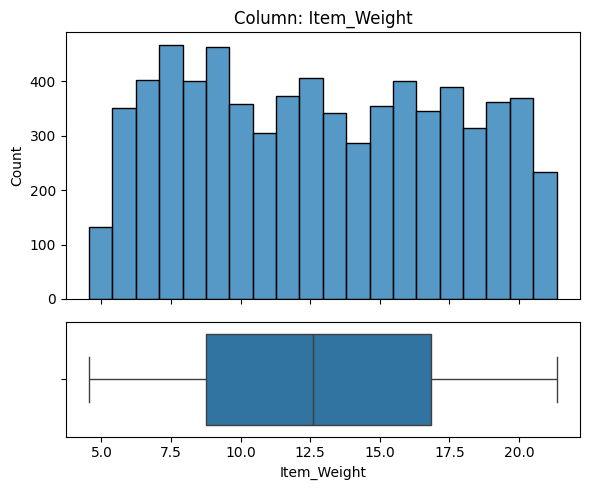

-- NaN's Found: 1463 (17.17%)


In [476]:
feature = 'Item_Weight'
explore_numeric(df, feature , figsize=(6,5))


## 2) Feature Observations

### Feature Type
- **Type:** Numeric

---

### Missing Values
- **Number of null values:** 1463
- **Percentage:** 17.17%

---

### Handling Missing Values
- To determine how to handle missing values, we need to check whether:
  - Incomplete data entry or missing product information.
  - The same product appearing multiple times with some entries missing weight values.

In [477]:
# Missing values in *Item_Weight* were imputed using the mean weight of each product (Item_Identifier) to preserve product-specific information.
df['Item_Weight'] = df['Item_Weight'].fillna(
    df.groupby('Item_Identifier')['Item_Weight'].transform('mean')
)
df['Item_Weight'].isna().sum()

np.int64(4)

In [478]:
# After imputing missing values using Item_Identifier-level means, 4 missing values still remained.
# To handle these, we performed a second imputation using Item_Type-level means,
# allowing similar product categories to share weight information and fill the remaining gaps.
df['Item_Weight'] = df['Item_Weight'].fillna(
    df.groupby('Item_Type')['Item_Weight'].transform('mean')
)


In [479]:
df['Item_Weight'].isna().sum()

np.int64(0)

 - What is the cardinality?

In [480]:
# High Cardinality
unique=df['Item_Weight'].nunique()
unique

450

 - Is the feature constant or quasi-constant?

In [481]:
values_num= df[feature].value_counts()
values_num

,count
Item_Weight,
12.150000,105
17.600000,102
13.650000,89
11.800000,86
15.100000,86
...,...
13.379905,1
6.635000,1
7.270000,1


In [482]:
most_common_value= values_num.index[0]
most_common_value

np.float64(12.15)

In [483]:
freq=values_num.values[0]
freq

np.int64(105)

In [484]:
# it's not a quasi constant or constant
perc_for_most_common = (freq/len(df)*100)
perc_for_most_common

np.float64(1.2319605772615276)

- Would we know this BEFORE the target is determined?
   Yes

- Is there a business case/understanding reason to exclude based on our business case?

  No, there is no business reason to exclude this feature. Item_Weight is a relevant characteristic that may influence pricing, logistics, and customer purchasing behavior, so it should be retained.

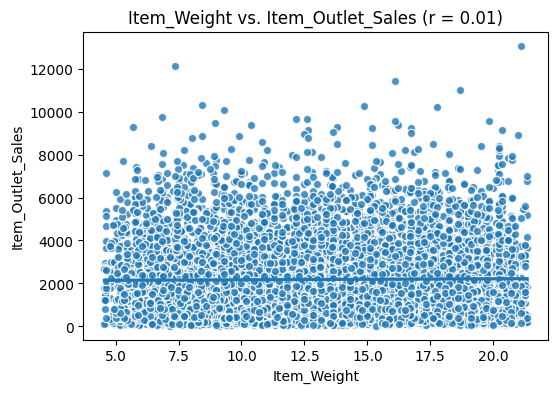

In [485]:
plot_numeric_vs_target(df,feature);

### 4) Feature vs. Target Observations


- Based on your business understanding, would you expect this feature to be a predictor of the target?    
  - Not necessarily. The effect of Item_Weight on sales is not direct, as it depends on the type of product. For example, in some cases such as skincare products, larger sizes may be more attractive, especially when combined with promotions or discounts. Therefore, the impact of weight varies across product categories and is not a consistent predictor of sales.

- Does this feature appear to be a predictor of the target?  
  - No, the plot shows no clear relationship between Item_Weight and Item_Outlet_Sales. The data points are widely scattered, and the correlation (r ≈ 0.01) is very close to zero, indicating almost no linear relationship.

In [486]:
df['Item_Type'].value_counts()

,count
Item_Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


## Item_Fat_Content : Whether the product is low fat or regular


In [487]:
df["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
low fat,5517
Regular,3006


/tmp/ipykernel_5979/19878224.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


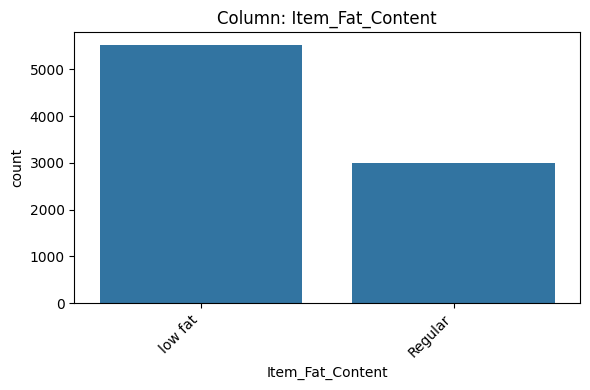

-- NaN's Found: 0 (0.0%)
-- Unique Values: 2
-- Most common value: 'low fat' occurs 5517 times (64.73%)
-- Not constant or quasi-constant.


In [488]:
feature2 = "Item_Fat_Content"
explore_categorical(df,feature2);


## 2) Feature Observations

### Feature Type
- **Type:** Categorical

---

### Missing Values
- **Number of null values:** 0
- **Percentage:** 0%

### Is the feature constant or quasi-constant?  
  - No, the most common value only occurs in 64% of the values. The threshold for quasi-constant is more than 98%.

### What is the cardinality? Is it high?  
  - There are 2 unique values. This is less than 10, which is our threshold for high cardinality.

- Would we know this BEFORE the target is determined?  
  - Yes.

- Is there a business case/understanding reason to exclude based on our business case?  
  - No




/tmp/ipykernel_5979/1034836275.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


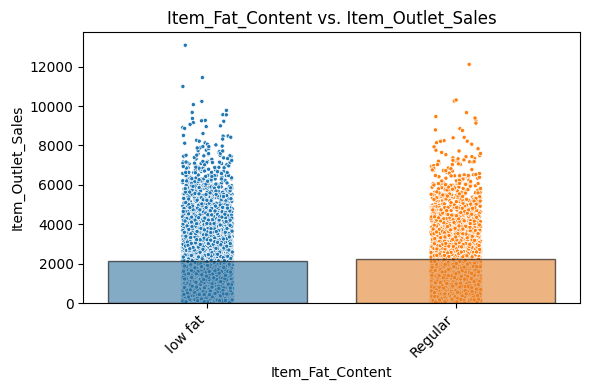

In [489]:
plot_categorical_vs_target(df, feature2);

- Based on your business understanding, would you expect this feature to be a predictor of the target?  
  - Not strongly. While fat content may influence customer preferences, it is unlikely to have a major direct impact on sales compared to other factors such as price, product type, or visibility.

- Does this feature appear to be a predictor of the target?  
  - No, the plot shows very similar distributions for low-fat and regular products, with significant overlap. This suggests that Item_Fat_Content is not a strong predictor of Item_Outlet_Sales.


## Item_Visibility : The percentage of total display area of all products in a store allocated to the particular product


In [490]:
df["Item_Visibility"].dtype

dtype('float64')

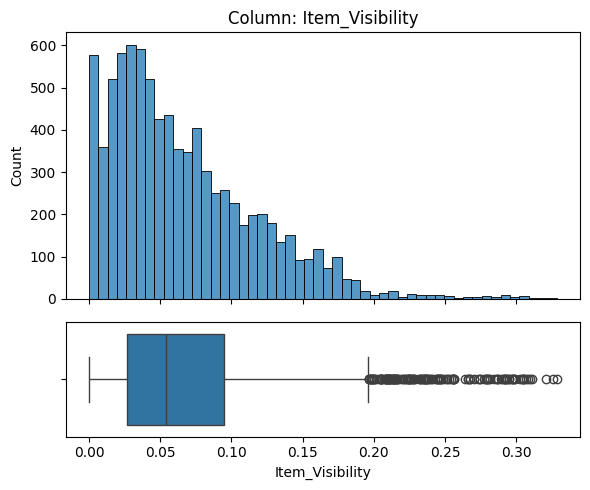

-- NaN's Found: 0 (0.0%)


In [491]:
feature3 = "Item_Visibility"
explore_numeric(df,feature3);

## 2) Feature Observations

### Feature Type
- **Type:** Numeric

---

### Missing Values
- **Number of null values:** 0
- **Percentage:** 0%


 - What is the cardinality?

In [492]:
# high cardinality
unique2=df['Item_Visibility'].nunique()
unique2

7880

In [493]:
values_num2= df[feature3].value_counts()
values_num2

,count
Item_Visibility,
0.000000,526
0.076975,3
0.061271,2
0.046825,2
0.112399,2
...,...
0.054142,1
0.018920,1
0.044974,1


In [494]:
most_common_value2= values_num.index[0]
most_common_value2

np.float64(12.15)

In [495]:
freq2 = values_num.values[0]
freq2

np.int64(105)

- quasi constant or constant

In [496]:
# it's not a quasi constant or constant
perc_for_most_common2 = (freq2/len(df)*100)
perc_for_most_common2

np.float64(1.2319605772615276)

- Would we know this BEFORE the target is determined?
    - Yes, Item_Visibility is determined by product placement and store layout, which are known before any sales occur.

Is there a business case/understanding reason to exclude based on our business case?
No

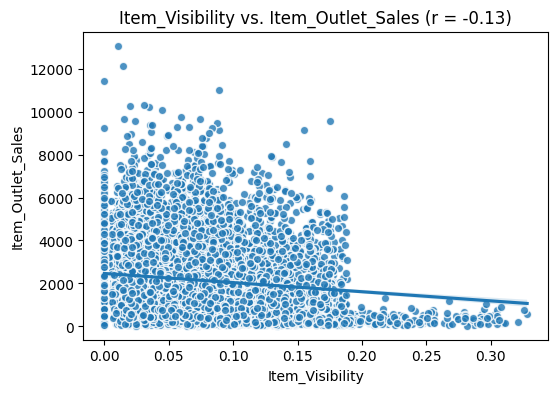

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Visibility vs. Item_Outlet_Sales (r = -0.13)'}, xlabel='Item_Visibility', ylabel='Item_Outlet_Sales'>)

In [497]:
plot_numeric_vs_target(df,feature3)

The plot shows a very weak negative relationship between Item_Visibility and Item_Outlet_Sales (r ≈ -0.13). The data points are highly scattered, indicating no strong linear relationship. This suggests that visibility is not a strong predictor of sales, and its effect may be influenced by other factors such as product type, price, or store strategy.

### Q1: Based on your business understanding, would you expect this feature to be a predictor of the target?

No, from a business perspective, allocating more display space to a product does not necessarily mean it will achieve higher sales. A product may occupy a large space but be placed in a less favorable position (e.g., too high, too low, or in a less visible area), which reduces its effectiveness. Therefore, display space alone is not a reliable predictor of sales.


---

### Q2: Does this feature appear to be a predictor of the target?

No, the feature does not appear to be a strong predictor of the target. The scatter plot shows a very weak negative correlation (r = -0.13) and no clear pattern, indicating that item visibility (display space) has little to no impact on sales.

## Item Type: The category to which the product belongs


In [498]:
df["Item_Type"].value_counts()

,count
Item_Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


/tmp/ipykernel_5979/19878224.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


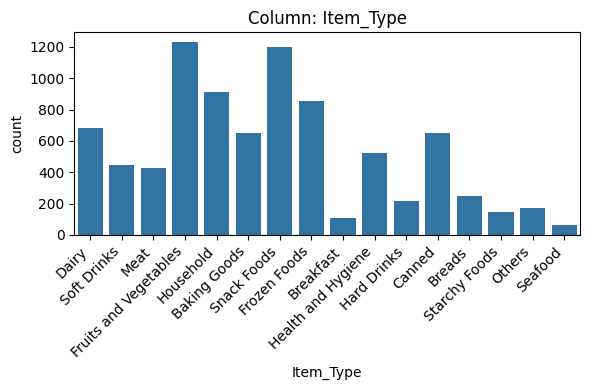

-- NaN's Found: 0 (0.0%)
-- Unique Values: 16
-- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
-- Not constant or quasi-constant.


In [499]:
feature4 = "Item_Type"
explore_categorical(df,feature4);


## 2) Feature Observations

### Feature Type
- **Type:** Categorical

---

### Missing Values
- **Number of null values:** 0
- **Percentage:** 0%

### Is the feature constant or quasi-constant?  
  - No, the most common value only occurs in 14% of the values. The threshold for quasi-constant is more than 98%.

### What is the cardinality? Is it high?  
  - There are 16 unique values. This is high cardinality.

- Would we know this BEFORE the target is determined?  
   - Yes, the product type is a predefined characteristic of the item and is known before any sales occur.

- Is there a business case/understanding reason to exclude based on our business case?  
  - No, there is no business reason to exclude this feature. Item_Type is an important factor that can influence customer preferences and purchasing behavior, as different product categories may have different demand levels and sales patterns.


/tmp/ipykernel_5979/1034836275.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


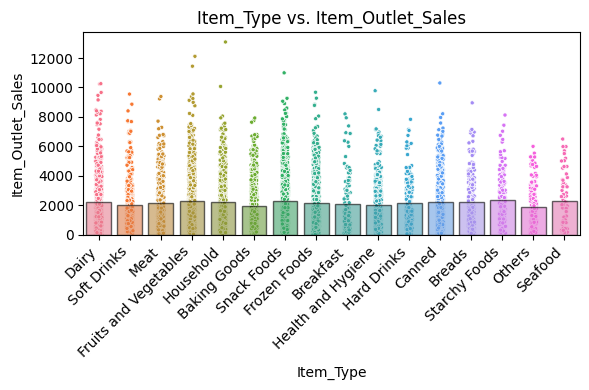

In [500]:
plot_categorical_vs_target(df, feature4);


### Q1: Based on your business understanding, would you expect this feature to be a predictor of the target?


Yes, from a business perspective, different product types are expected to influence sales, as some categories are more in demand than others.


---

### Q2: Does this feature appear to be a predictor of the target?


The feature shows some variation in sales across categories, but the distributions are quite similar with significant overlap, indicating that it is not a strong predictor of the target.



## Item_MRP: Maximum Retail Price (list price) of the product

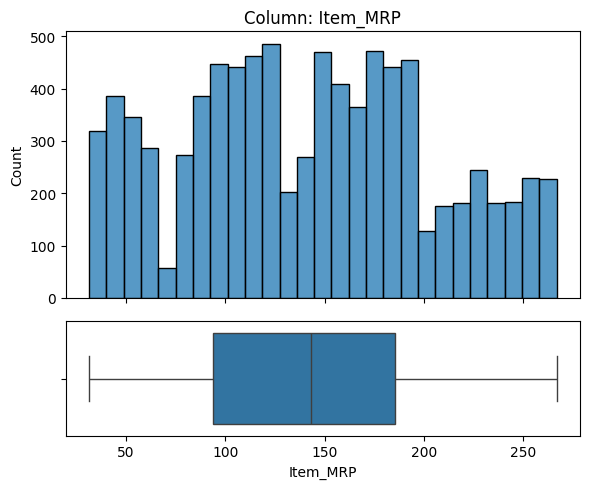

-- NaN's Found: 0 (0.0%)


In [501]:
feature5 = "Item_MRP"
explore_numeric(df,feature5);

## 2) Feature Observations

### Feature Type
- **Type:** Numeric

---

### Missing Values
- **Number of null values:** 0
- **Percentage:** 0%
---



In [502]:
values_num3 = df[feature5].value_counts()
values_num3

,count
Item_MRP,
172.0422,7
170.5422,6
142.0154,6
109.5228,6
188.1872,6
...,...
108.7912,1
157.5972,1
245.2118,1


In [503]:

freq3 = values_num3.values[0]
freq3

np.int64(7)

In [504]:
most_common_value3 = values_num3.index[0]
most_common_value3

np.float64(172.0422)

- constant or quasi-constant ? None

In [505]:
# constant or quasi-constant
perc_for_most_common3 = (freq3 / len(df) * 100)
perc_for_most_common3

np.float64(0.08213070515076851)

- What is the cardinality? high, 5938 unique values

In [506]:
# high Cardinality
unique3=df[feature5].nunique()
unique3

5938

- Would we know this BEFORE the target is determined?
Yes

- Is there a business case/understanding reason to exclude based on our business case?
 No, there is no reason to exclude this feature. Price is a fundamental factor in sales, as it directly influences customer purchasing decisions, making it highly relevant to the business case.

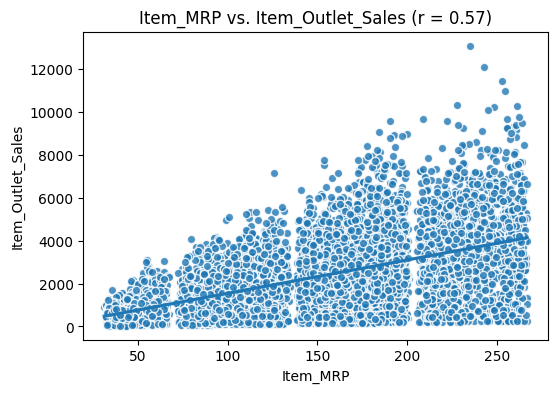

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_MRP vs. Item_Outlet_Sales (r = 0.57)'}, xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>)

In [507]:
plot_numeric_vs_target(df,feature5)

### Q1: Based on your business understanding, would you expect this feature to be a predictor of the target?

   - Yes. Higher-priced items are expected to influence sales.
---

### Q2: Does this feature appear to be a predictor of the target?

  -  Yes. The plot shows a moderate positive relationship (r = 0.57), indicating it is a useful predictor.

# Outlet_Establishment_Year: the year which the store was establishment

In [508]:
feature6 = "Outlet_Establishment_Year"
df['Outlet_Establishment_Year']

,Outlet_Establishment_Year
0,1999
1,2009
2,1999
3,1998
4,1987
...,...
8518,1987
8519,2002
8520,2004
8521,2009


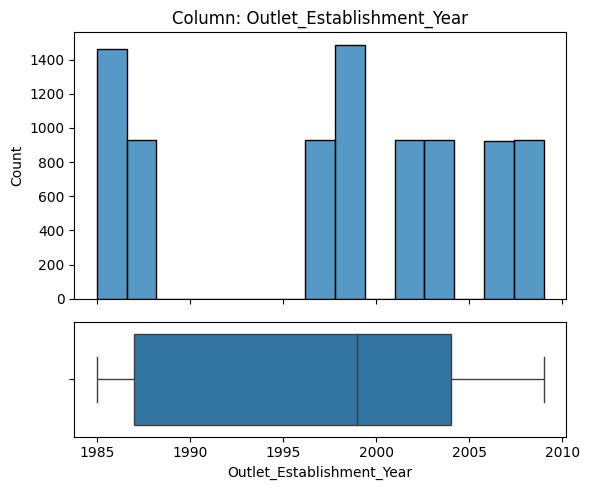

-- NaN's Found: 0 (0.0%)


In [509]:
explore_numeric(df, feature6 , figsize=(6,5))

## 2) Feature Observations

### Feature Type
- **Type:** Numeric

---

### Missing Values
- **Number of null values:** 0
- **Percentage:** 0%
---

In [510]:
values_num4 = df[feature6].value_counts()
values_num4

,count
Outlet_Establishment_Year,
1985,1463
1987,932
1999,930
1997,930
2004,930
2002,929
2009,928
2007,926
1998,555


In [511]:
freq4= values_num4.values[0]
freq4

np.int64(1463)

In [512]:
most_common_value4 = values_num4.index[0]
most_common_value4

np.int64(1985)

- not constant or quasi-constant

In [513]:
# not constant or quasi-constant
perc_for_most_common4 = (freq4 / len(df) * 100)
perc_for_most_common4

np.float64(17.165317376510618)

- low cardinality

In [514]:
# low Cardinality
unique4=df[feature6].nunique()
unique4

9

- Would we know this BEFORE the target is determined?
Yes

- Is there a business case/understanding reason to exclude based on our business case?
No, because even though it does not directly affect sales, older outlets may have more experience and loyal customers, which can influence sales.

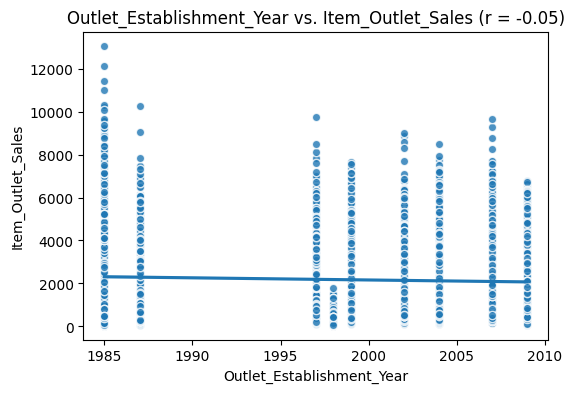

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Establishment_Year vs. Item_Outlet_Sales (r = -0.05)'}, xlabel='Outlet_Establishment_Year', ylabel='Item_Outlet_Sales'>)

In [515]:
plot_numeric_vs_target(df,feature6)

The scatter plot shows a very weak relationship between Outlet_Establishment_Year and Item_Outlet_Sales, with a correlation of approximately -0.05.

The data points are widely scattered with no clear upward or downward trend, and the regression line is almost flat. This indicates that the year in which the outlet was established does not significantly influence sales.

### Q1: Based on your business understanding, would you expect this feature to be a predictor of the target?

   - I was not very confident about this feature as a predictor. On one hand, older outlets might have higher sales due to their established reputation and loyal customer base. On the other hand, newer outlets could also achieve higher sales because of modern marketing strategies and more attractive designs that appeal to customers.
  Therefore, I did not have a strong expectation, and my assumption about its impact on sales was relatively low.
---

### Q2: Does this feature appear to be a predictor of the target?

  -  no

# Outlet_size: the size of the store in terms of ground area covered

In [516]:
feature7= "Outlet_Size"
df[feature7].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


/tmp/ipykernel_5979/19878224.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


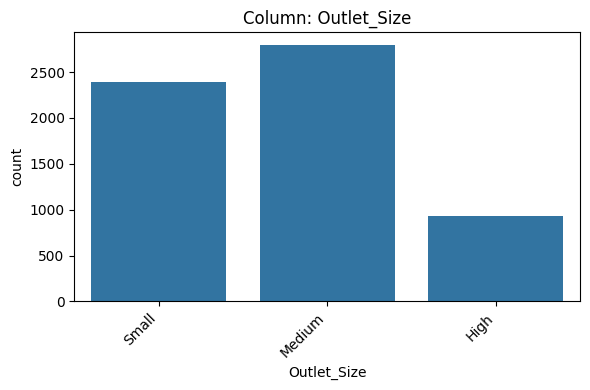

-- NaN's Found: 2410 (28.28%)
-- Unique Values: 4
-- Most common value: 'Medium' occurs 2793 times (32.77%)
-- Not constant or quasi-constant.


In [517]:
order = ['Small', 'Medium', 'High']
explore_categorical(df,feature7, order= order);

## 2) Feature Observations

### Feature Type
- **Type:** Categorical (ordinal)

---

### Missing Values
- **Number of null values:** 2410
- **Percentage:** 28.28%
---
### Is the feature constant or quasi-constant?  
  - No, the most common value only occurs in 32.77%% of the values. The threshold for quasi-constant is more than 98%.

### What is the cardinality? Is it high?  
  - There are 2 unique values. This is less than 4, which is our threshold for high cardinality.


In [518]:
df['Outlet_Identifier'].value_counts()

,count
Outlet_Identifier,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555


In [519]:
# Check if any outlet group has all missing values in Outlet_Size
df.groupby('Outlet_Identifier')[feature7].apply(lambda x: x.isna().all())

,Outlet_Size
Outlet_Identifier,
OUT010,True
OUT013,False
OUT017,True
OUT018,False
OUT019,False
OUT027,False
OUT035,False
OUT045,True
OUT046,False


In [520]:
# Impute missing values in Outlet_Size:
# 1) Fill using the mode within each outlet (Outlet_Identifier)
df[feature7] = df[feature7].fillna(
    df.groupby('Outlet_Identifier')[feature7].transform(
        lambda x: x.mode()[0] if not x.mode().empty else None
    )
)

# 2) Fill remaining missing values using Outlet_Type-level mode
df[feature7] = df[feature7].fillna(
    df.groupby('Outlet_Type')[feature7].transform(
        lambda x: x.mode()[0] if not x.mode().empty else None
    )
)

In [521]:
df[feature7].isna().sum()

np.int64(0)

- Would we know this BEFORE the target is determined?
Yes

- Is there a business case/understanding reason to exclude based on our business case?
No

/tmp/ipykernel_5979/1034836275.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


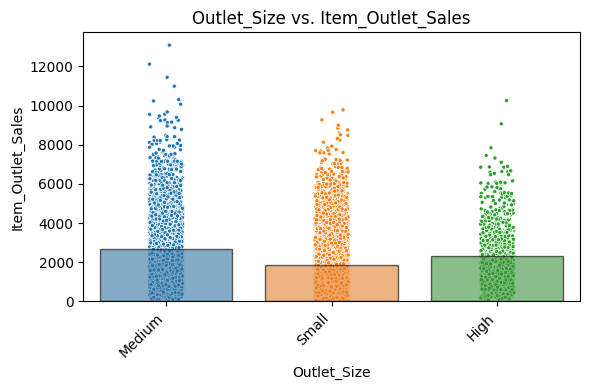

In [522]:
plot_categorical_vs_target(df, feature7);

The plot shows that Medium-sized outlets tend to have the highest average sales, followed by High, while Small outlets generally have the lowest sales.

There is a noticeable difference between the categories, indicating that outlet size has an impact on sales. Larger and medium outlets likely benefit from more space, better product visibility, and higher customer traffic.



### Q1: Based on your business understanding, would you expect this feature to be a predictor of the target?

   - Yes, I would expect this feature to be a predictor.
     Outlet size can directly influence sales, as larger outlets can display more products, attract more customers, and provide a better shopping experience, while smaller outlets may have limited capacity and lower sales potential.
---

### Q2: Does this feature appear to be a predictor of the target?

  -  Yes, this feature appears to be a predictor of the target.
     The plot shows clear differences in sales across outlet sizes, with Medium outlets having the highest sales, followed by High, and Small outlets having the lowest. This indicates that outlet size has a noticeable impact on sales.

### Outlet_Location_Type: The type of the area in which the store is located

In [523]:
df['Outlet_Location_Type'].dtype

dtype('O')

In [524]:
feature8 = 'Outlet_Location_Type'

In [525]:
df[feature8].value_counts()

,count
Outlet_Location_Type,
Tier 3,3350
Tier 2,2785
Tier 1,2388


/tmp/ipykernel_5979/19878224.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


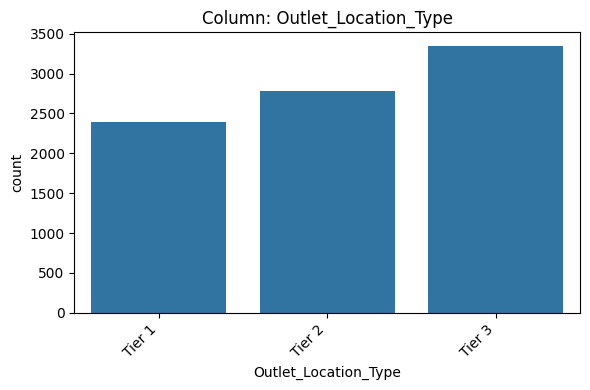

-- NaN's Found: 0 (0.0%)
-- Unique Values: 3
-- Most common value: 'Tier 3' occurs 3350 times (39.31%)
-- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Outlet_Location_Type'}, xlabel='Outlet_Location_Type', ylabel='count'>)

In [526]:
order1 = ['Tier 1', 'Tier 2', 'Tier 3']
explore_categorical(df, feature8, order=order1)


## 2) Feature Observations

### Feature Type
- **Type:** Categorical(ordinal)

---

### Missing Values
- **Number of null values:** 0
- **Percentage:** 0%


### Is the feature constant or quasi-constant?  
  - No, the most common value only occurs in 39.31% of the values. The threshold for quasi-constant is more than 98%.

### What is the cardinality? Is it high?  
  - There are 3 unique values. This is low cardinality.

- Would we know this BEFORE the target is determined?
Yes

- Is there a business case/understanding reason to exclude based on our business case?
No

/tmp/ipykernel_5979/1034836275.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


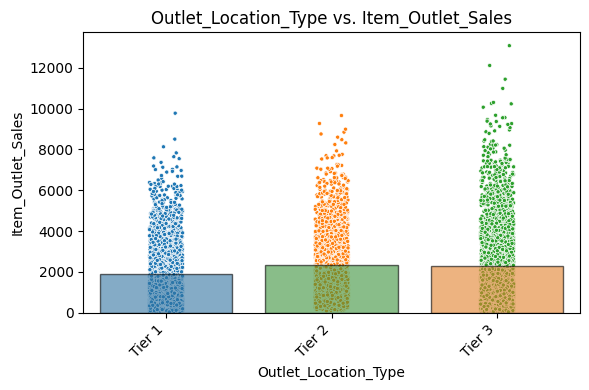

In [527]:
plot_categorical_vs_target(df, feature8,order=order1);

### Q1: Based on your business understanding, would you expect this feature to be a predictor of the target?

   - Yes, I would expect this feature to be a predictor.
---

### Q2: Does this feature appear to be a predictor of the target?

  -  Yes, this feature appears to be a predictor of the target.
     The plot shows a clear difference in sales across location types, with Tier 3 having the highest sales, followed by Tier 2, and Tier 1 having the lowest. This indicates that outlet location has a noticeable impact on sales.

### Outlet_Type: Whether the outlet is a grocery store or some sort of supermarket

In [528]:
df['Outlet_Type'].dtype

dtype('O')

In [529]:
feature9 = 'Outlet_Type'

In [530]:
df[feature9].value_counts()

,count
Outlet_Type,
Supermarket Type1,5577
Grocery Store,1083
Supermarket Type3,935
Supermarket Type2,928


/tmp/ipykernel_5979/19878224.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


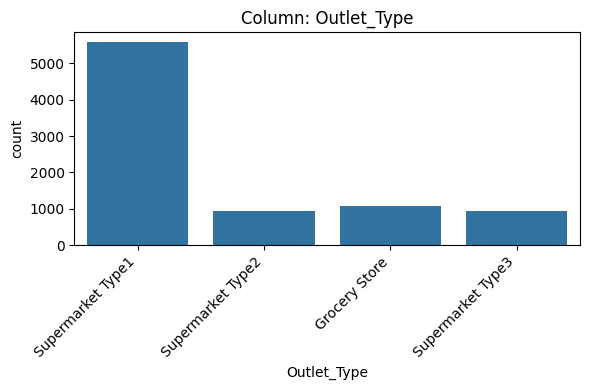

-- NaN's Found: 0 (0.0%)
-- Unique Values: 4
-- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
-- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Outlet_Type'}, xlabel='Outlet_Type', ylabel='count'>)

In [531]:
explore_categorical(df, feature9)


## 2) Feature Observations

### Feature Type
- **Type:** Categorical

---

### Missing Values
- **Number of null values:** 0
- **Percentage:** 0%


### Is the feature constant or quasi-constant?  
  - No, the most common value only occurs in 65.43%% of the values. The threshold for quasi-constant is more than 98%.

### What is the cardinality? Is it high?  
  - There are 4 unique values. This is low cardinality.

- Would we know this BEFORE the target is determined?
Yes
- Is there a business case/understanding reason to exclude based on our business case?
No

/tmp/ipykernel_5979/1034836275.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


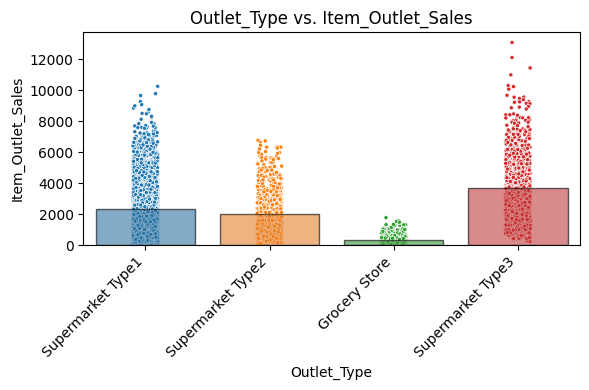

In [532]:
plot_categorical_vs_target(df, feature9);

The plot shows that Supermarket Type 3 has the highest sales, followed by Supermarket Type 1, then Supermarket Type 2, while Grocery Stores have the lowest sales by a large margin.

There is a clear difference between outlet types, indicating that the type of store has a strong impact on sales. Supermarkets, especially Type 3, generate significantly higher sales compared to grocery stores, likely due to larger size, wider product variety, and higher customer traffic.

### Q1: Based on your business understanding, would you expect this feature to be a predictor of the target?

   - Yes, I would expect this feature to be a strong predictor.
     Different outlet types vary in size, product variety, and customer capacity. Supermarkets typically offer a wider range of products and attract more customers compared to grocery stores, which suggests they are likely to generate higher sales.
---

### Q2: Does this feature appear to be a predictor of the target?

  -  Yes, this feature appears to be a strong predictor of the target. The plot shows clear differences in sales across outlet types, with Supermarket Type 3 having the highest sales and Grocery Stores having the lowest. This indicates that outlet type has a significant impact on sales.